# CT Annotation Benchmark

Consumes `ms_annotation.h5ad` from each of the 5 wrappers, aligns by `obs_names`,
computes uniform metrics, and produces:
1. A metrics DataFrame (accuracy, macro-precision/recall/F1)
2. A 1×5 grid of normalized confusion matrices
3. A 2×3 grid of UMAPs colored by ground truth + each model's predictions

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)

MODELS = ["scGPT", "cellPLM", "Geneformer", "scFoundation", "scVI"]
ROOT = Path("/data/benchmark/ct_annotation")
GROUND_TRUTH = "/data/benchmark/data/cellPLM/data/filtered_ms_adata.h5ad"

In [2]:
# --- Load ground truth ---
gt = ad.read_h5ad(GROUND_TRUTH)
LABEL_COL = "Factor Value[inferred cell type - authors labels]"
gt.obs["celltype"] = gt.obs[LABEL_COL].astype(str)
print(f"ground truth: n_obs={gt.n_obs}, n_classes={gt.obs['celltype'].nunique()}")

ground truth: n_obs=13468, n_classes=18


In [3]:
# --- Load each wrapper's predictions; align by obs_names ---
preds_per_model: dict[str, np.ndarray] = {}
for m in MODELS:
    p = ROOT / f"{m}-annotation-wrapper" / "ms_annotation.h5ad"
    if not p.exists():
        print(f"SKIP {m}: {p} does not exist")
        continue
    out = ad.read_h5ad(p)
    # Align: reindex by gt.obs_names.
    common = gt.obs_names.intersection(out.obs_names)
    assert len(common) == gt.n_obs == out.n_obs, (
        f"{m}: gt={gt.n_obs}, wrapper={out.n_obs}, common={len(common)}"
    )
    out = out[gt.obs_names].copy()
    gt.obs[f"{m}_pred"] = out.obs["predictions"].astype(str).values
    preds_per_model[m] = out.obs["predictions"].astype(str).values

print(f"loaded predictions for: {list(preds_per_model.keys())}")

loaded predictions for: ['scGPT', 'cellPLM', 'Geneformer', 'scFoundation', 'scVI']


In [4]:
# --- Metrics table ---
rows = []
y_true = gt.obs["celltype"].astype(str).values
for m, y_pred in preds_per_model.items():
    rows.append({
        "model": m,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    })
metrics_df = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
print(metrics_df.to_string(index=False))

       model  accuracy  macro_precision  macro_recall  macro_f1
     cellPLM  0.888031         0.799795      0.772160  0.776523
        scVI  0.867464         0.751585      0.762241  0.742871
scFoundation  0.833828         0.778911      0.710122  0.702189
  Geneformer  0.831007         0.726413      0.679818  0.685215
       scGPT  0.846302         0.688008      0.695509  0.663136


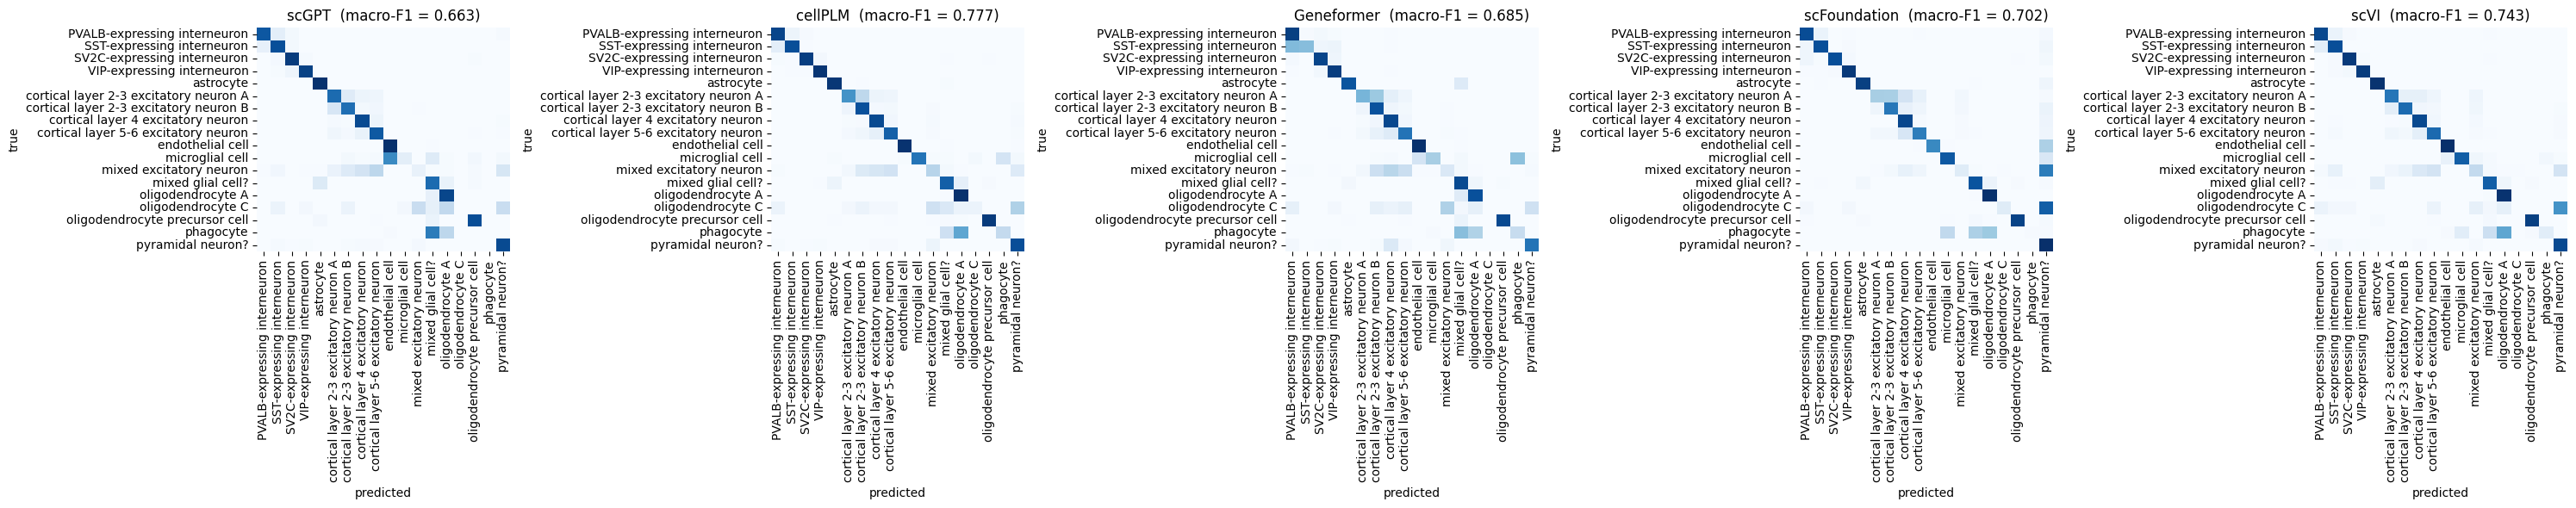

In [5]:
# --- Confusion matrix grid (1×N) ---
classes = sorted(set(y_true) | {c for preds in preds_per_model.values() for c in preds})
n = len(preds_per_model)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
if n == 1:
    axes = [axes]
for ax, (m, y_pred) in zip(axes, preds_per_model.items()):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    sns.heatmap(cm_norm, xticklabels=classes, yticklabels=classes, cmap="Blues", ax=ax, cbar=False, vmin=0, vmax=1)
    ax.set_title(f"{m}  (macro-F1 = {metrics_df.set_index('model').loc[m, 'macro_f1']:.3f})")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.savefig(ROOT / "confusion_matrices.png", dpi=150)
plt.show()

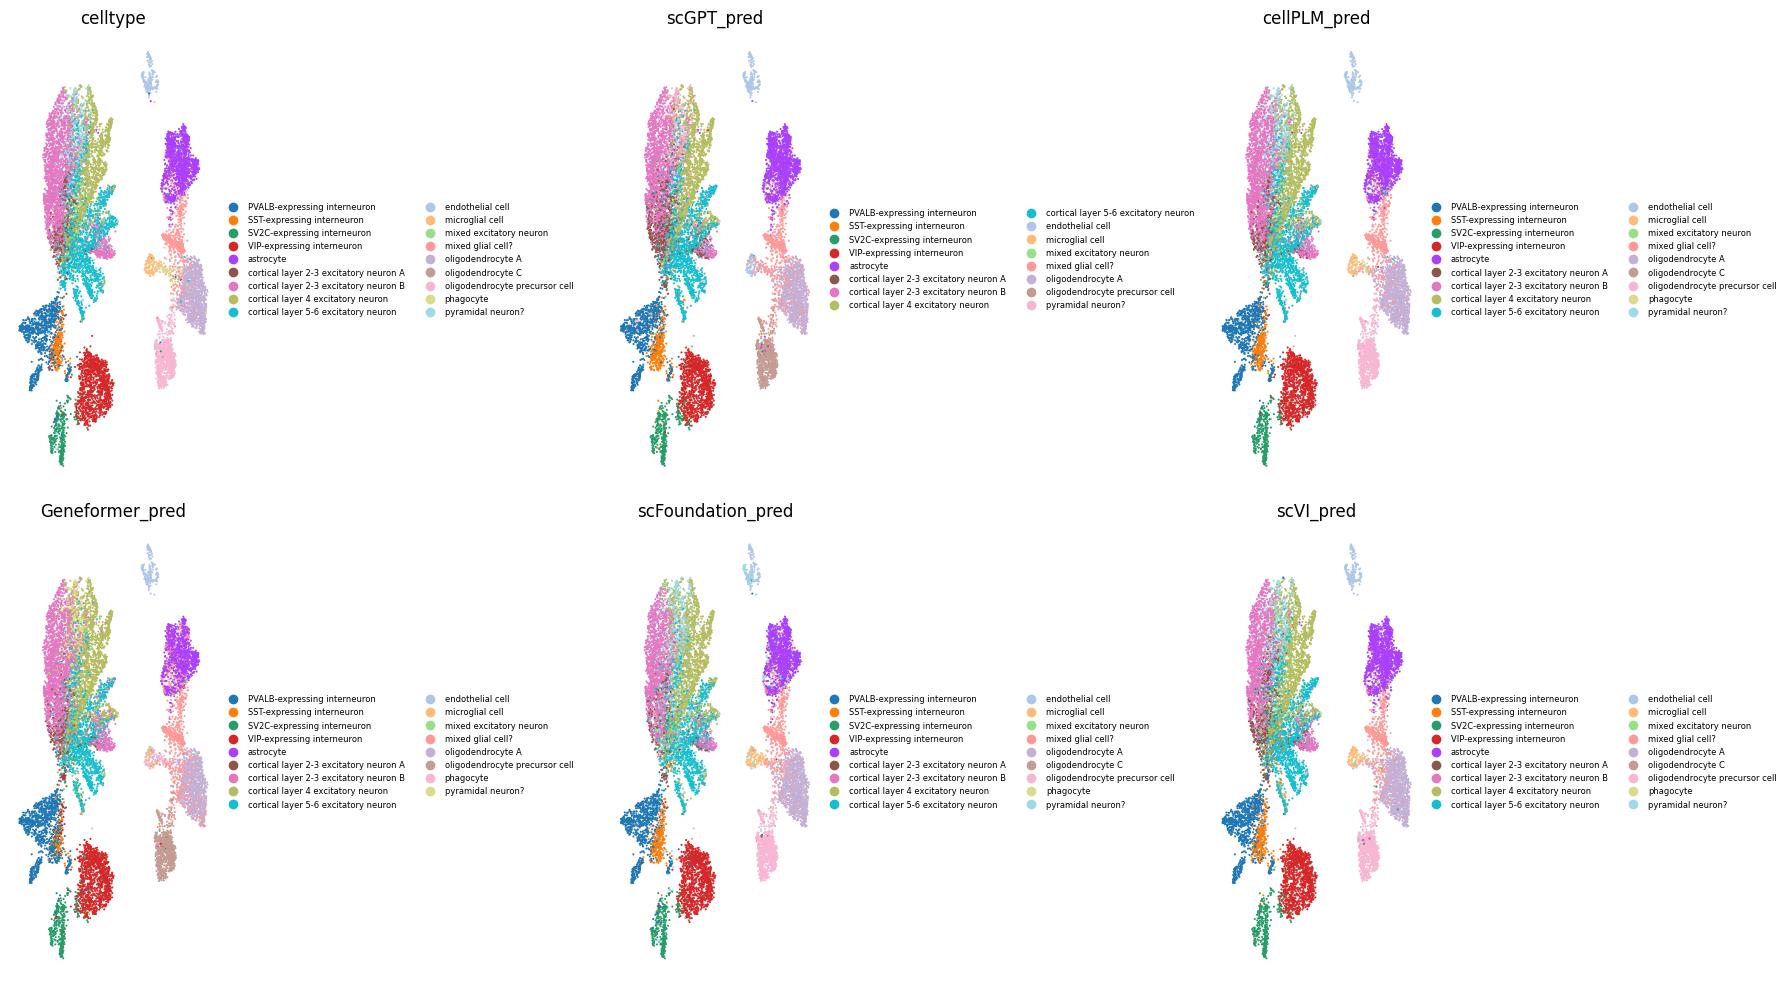

In [6]:
# --- UMAP comparison ---
# Compute one shared UMAP on gt.
adata_umap = gt.copy()
if "log1p" not in adata_umap.uns:
    # filtered_ms_adata.h5ad is already log-normed in our pipeline. Recompute fresh to be safe.
    sc.pp.normalize_total(adata_umap, target_sum=1e4)
    sc.pp.log1p(adata_umap)
sc.pp.highly_variable_genes(adata_umap, n_top_genes=2000)
adata_umap = adata_umap[:, adata_umap.var.highly_variable].copy()
sc.pp.scale(adata_umap, max_value=10)
sc.pp.pca(adata_umap, n_comps=50, random_state=0)
sc.pp.neighbors(adata_umap, random_state=0)
sc.tl.umap(adata_umap, random_state=0)
# Copy prediction columns over.
for m, y_pred in preds_per_model.items():
    adata_umap.obs[f"{m}_pred"] = pd.Categorical(y_pred)

panels = ["celltype"] + [f"{m}_pred" for m in preds_per_model.keys()]
n_cols = 3
n_rows = int(np.ceil(len(panels) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()
for ax, color in zip(axes, panels):
    sc.pl.umap(adata_umap, color=color, show=False, ax=ax, legend_fontsize=6, frameon=False)
    ax.set_title(color)
for ax in axes[len(panels):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(ROOT / "umap_comparison.png", dpi=150)
plt.show()

In [7]:
# --- Save metrics CSV for downstream use ---
metrics_df.to_csv(ROOT / "metrics.csv", index=False)
print("wrote", ROOT / "metrics.csv")

wrote /data/benchmark/ct_annotation/metrics.csv
